In [1]:
import sys
sys.path.append("../../..")
import torch
from torch.distributions import Normal
from sbi.inference import SMCABC
from sbi.analysis import pairplot
import numpy as np
import matplotlib.pyplot as plt
import scipy
from numbers import Number

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


We hypothesize that SNPE-A will struggle to provide a good posterior approximation when the prior (or proposal) mass is far from the posterior mass. 

We can test this in 1D by considering the following example:

$$p(\theta) = N(\theta ; 0, 1)$$

$$p(x|\theta) = N(x; \theta , 1)$$

where we observe $x_\text{obs}\in \{0,1,2,3,...\}$ ($x_\text{obs}$ is $x_\text{obs}$ standard deviations above the mean of the prior). In this case, we have a posterior given analytically by

$$p(\theta|x_\text{obs}) = N\left(\theta; \frac{x_\text{obs}}{2}, \frac{1}{2}\right)$$

We expect that, for large enough $x$ (think over $\approx 4\sigma$ away from prior mean), the SNPE-A algorithm will struggle to approximate the true posterior, since it will be extrapolating past the $(x, \theta)$ training pairs. 

Note that the SNPE-A algorithm (and therefore the python implementation from `sbi`) only allows Gaussian or uniform priors.

In [2]:
from src.examples.norm_norm_far_1d import prior_pdf, likelihood_pdf, posterior_pdf, plot_approximate_posterior, prior, simulator

# Amortized Inference with NPE-A

In [ ]:
class SMCPosterior:
    def __init__(self, num_particles, num_initial_pop, num_simulations, epsilon_decay):
        self.num_particles = num_particles
        self.num_initial_pop = num_initial_pop
        self.num_simulations = num_simulations
        self.epsilon_decay = epsilon_decay
        self.inference = SMCABC(prior=prior, simulator=simulator, distance="l2", show_progress_bars=False)  # (S)NPE-A algorithm (fast epsilon-free inference)

    def sample(self, sample_shape, x, show_progress_bars=False):
        # Return samples from the KDE
        kde_wrapper, summary = self.inference(
            x_o = x,
            num_particles=self.num_particles,
            num_initial_pop=self.num_initial_pop,   # Initial population, more is better
            num_simulations=self.num_simulations,  # Total simulations budget
            epsilon_decay=self.epsilon_decay,      # Slower decay helps stabilize
            return_summary=True,
            kde=True
        )
        self.summary = summary
        return kde_wrapper.sample(sample_shape)

    def approximate_posterior(self, theta, x_o):
        # Return samples from the KDE
        kde_wrapper, summary = self.inference(
            x_o = x_o,
            num_particles=self.num_particles,
            num_initial_pop=self.num_initial_pop,   # Initial population, more is better
            num_simulations=self.num_simulations,  # Total simulations budget
            epsilon_decay=self.epsilon_decay,      # Slower decay helps stabilize
            return_summary=True,
            kde=True
        )
        self.summary = summary
        # Return log probability of given parameters
        return torch.exp(kde_wrapper.log_prob(theta))


In [4]:
num_particles = 1000
num_initial_pop = 5000
num_simulations = 100000
epsilon_decay = 0.8
posterior = SMCPosterior(num_particles, num_initial_pop, num_simulations, epsilon_decay)

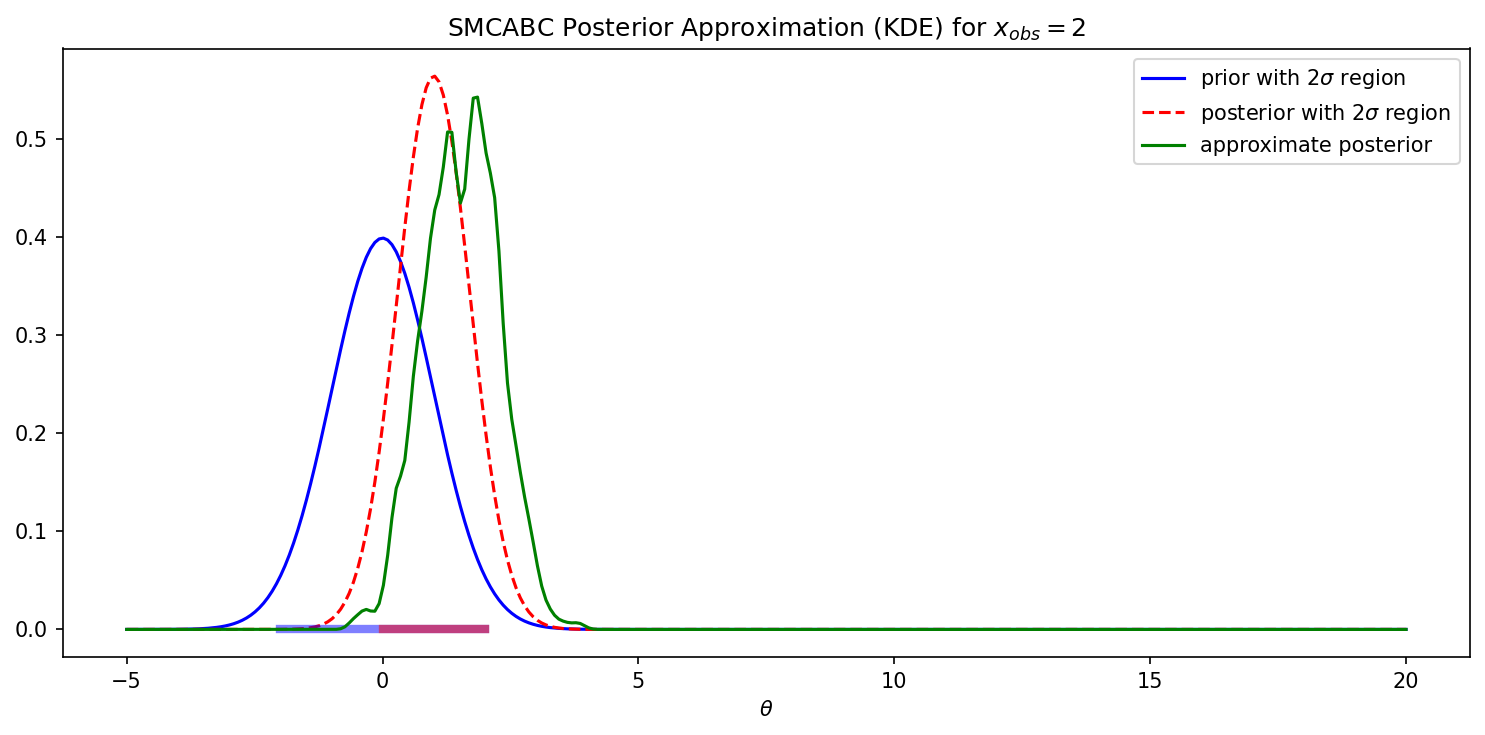

In [5]:
x_observed = 2 # Observed data
theta_range = torch.linspace(-5,20,300).view(-1,1)
plot_approximate_posterior(posterior.approximate_posterior, prior_pdf, posterior_pdf, theta_range, x_observed, title=r"SMCABC Posterior Approximation (KDE) for $x_{obs} = $" + f"{x_observed}")

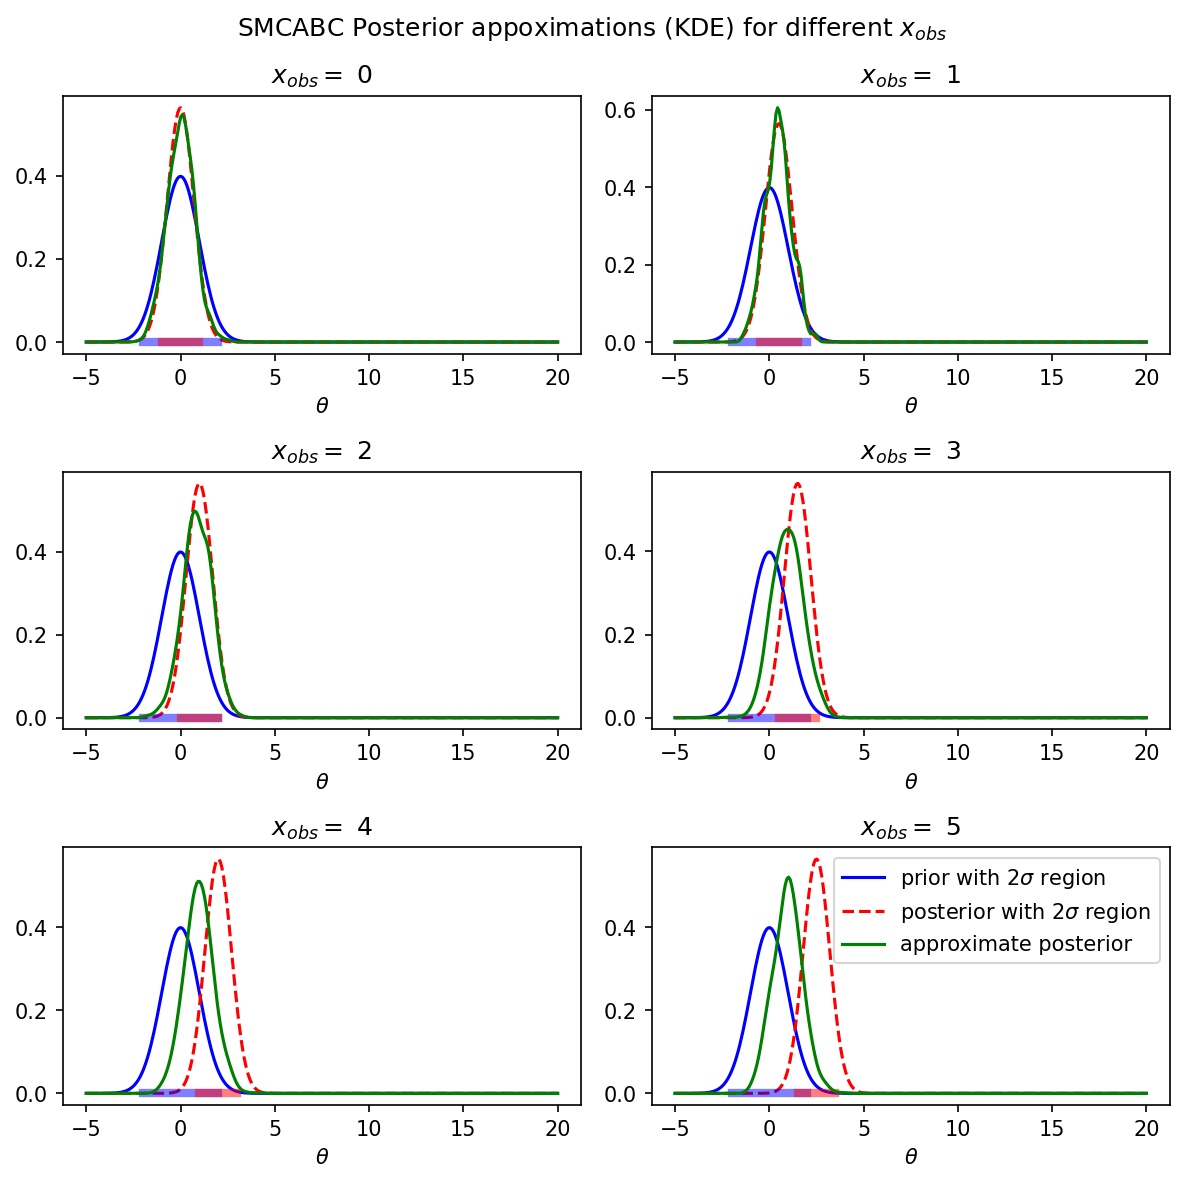

In [6]:
x_observed_values = [0, 1, 2, 3, 4, 5]
theta_range = torch.linspace(-5,20,300).view(-1,1)
plot_approximate_posterior(posterior.approximate_posterior, prior_pdf, posterior_pdf, theta_range, x_observed_values, title=r"SMCABC Posterior appoximations (KDE) for different $x_{obs}$")

### SBC on SMCABC

In [7]:
from src.sbc.sbc_tools import sbc_ranks, plot_sbc_ecdf, plot_sbc_ecdf_diff, plot_sbc_histogram

In [10]:
N_iter = 100
N_samp = 1000
ranks = sbc_ranks(simulator, prior, posterior, N_iter=N_iter, N_samp=N_samp)

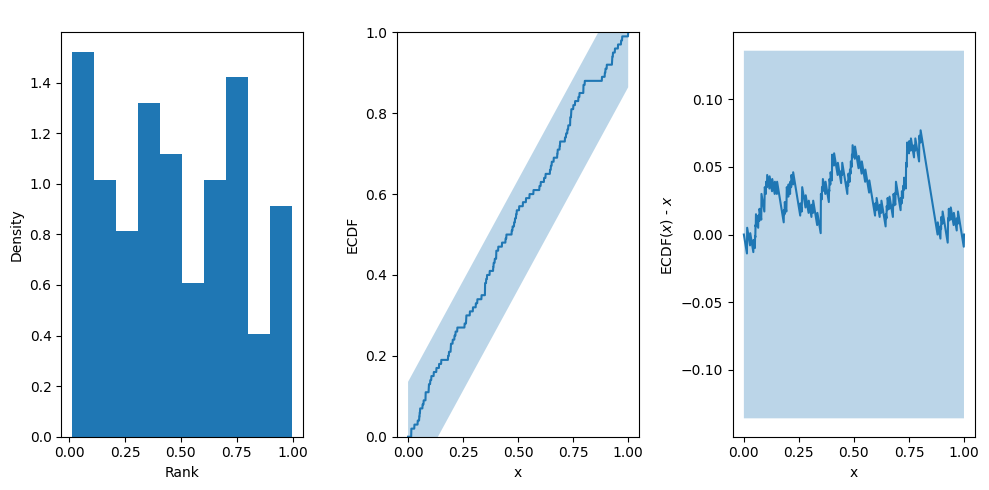

In [11]:
fig, ax = plt.subplots(figsize=(10,5), ncols=3)
plot_sbc_histogram(ranks, N_iter, N_samp, ax=ax[0], title=" ")
plot_sbc_ecdf(ranks, N_iter, N_samp, ax=ax[1], title=" ")
plot_sbc_ecdf_diff(ranks, N_iter, N_samp, ax=ax[2], title=" ")
plt.tight_layout()
plt.show()